## **Task 1. Data analysis**
**Points: 2**

**Make a thorough analysis of the data. Some possible questions to answer include (but is not limited to):**
• What patterns exist within the individual series?
• What relationships exist between the different series?
• Can the series be grouped? If so, indicate which groups you believe exist.

<br>
What other questions can you ask and answer? Extract as much information as you can and keep a critical mindset. It may be relevant to consider the returns of the price series, i.e., the change in price from one day to the next relative to the price itself (or alternatively the log-returns). While it is possible that the absolute price levels also contain useful information, in this case, it is probably a good approach to primarily work with returns.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import VAR
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(context='notebook', style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load the raw data

In [3]:
df_raw = pd.read_csv('../data/spiff_data-2.csv')
df_raw = df_raw.drop(columns=['Unnamed: 0']).set_index('day')
series_cols = df_raw.columns.tolist()
print(f'{len(df_raw)} days, {len(series_cols)} series: {series_cols}')
df_raw.head()

5456 days, 7 series: ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
1,6.154653,2.794285,2.136536,10.653684,3.324896,3.896149,7.755880
2,6.189623,2.843068,2.113582,10.674465,3.355736,3.899915,7.781310
3,6.168641,2.839644,2.116336,10.822372,3.336461,3.897404,7.886205
4,6.156401,2.823384,2.096137,10.848804,3.288274,3.901170,7.848061
5,6.124929,2.832798,2.099810,10.860731,3.303694,3.905355,7.883026


## 2. Data quality

### 2.1 The "1000" values

Five observations per series take the value exactly "1000". They are several orders of magnitude above the surrounding level and are treated as placeholders, not real observations. We replace them with NaN.

In [4]:
mask_1000 = df_raw == 1000
print('Count of 1000 values per series:')
print(mask_1000.sum())
print('\nLocations (day index) where 1000 appears:')
for c in series_cols:
    idx = df_raw.index[mask_1000[c]].tolist()
    print(f'  {c:<14} {idx}')

Count of 1000 values per series:
gurkor          5
guitars         5
slingshots      5
stocks          5
sugar           5
water           5
tranquillity    5
dtype: int64

Locations (day index) where 1000 appears:
  gurkor         [36, 1194, 2836, 3430, 4118]
  guitars        [36, 1194, 2836, 3430, 4118]
  slingshots     [36, 1194, 2836, 3430, 4118]
  stocks         [36, 1194, 2836, 3430, 4118]
  sugar          [36, 1194, 2836, 3430, 4118]
  water          [36, 1194, 2836, 3430, 4118]
  tranquillity   [36, 1194, 2836, 3430, 4118]


In [5]:
df = df_raw.replace(1000, np.nan)

### 2.2 NaN gaps

Each of the seven series has a contiguous block of NaN values, but the blocks sit at different places. We first locate each gap, then visualise it. Note: this also includes the longer "padding" at the end, this will be revisited in step 3.

In [6]:
def find_nan_gaps(s):
    """Return list of (start_day, end_day, length) for each contiguous NaN run."""
    is_nan = s.isna().values
    gaps = []
    i = 0
    n = len(is_nan)
    while i < n:
        if is_nan[i]:
            j = i
            while j < n and is_nan[j]:
                j += 1
            gaps.append((s.index[i], s.index[j - 1], j - i))
            i = j
        else:
            i += 1
    return gaps

gap_table = []
for c in series_cols:
    for start, end, length in find_nan_gaps(df[c]):
        gap_table.append({'series': c, 'start_day': start, 'end_day': end, 'length': length})
gap_df = pd.DataFrame(gap_table)
print('NaN runs per series (after replacing 1000 → NaN):')
gap_df

NaN runs per series (after replacing 1000 → NaN):


,series,start_day,end_day,length
0,gurkor,36,36,1
1,gurkor,199,248,50
2,gurkor,1194,1194,1
3,gurkor,2836,2836,1
4,gurkor,3430,3430,1
5,gurkor,4118,4118,1
6,gurkor,5257,5456,200
7,guitars,36,36,1
8,guitars,399,448,50
9,guitars,1194,1194,1


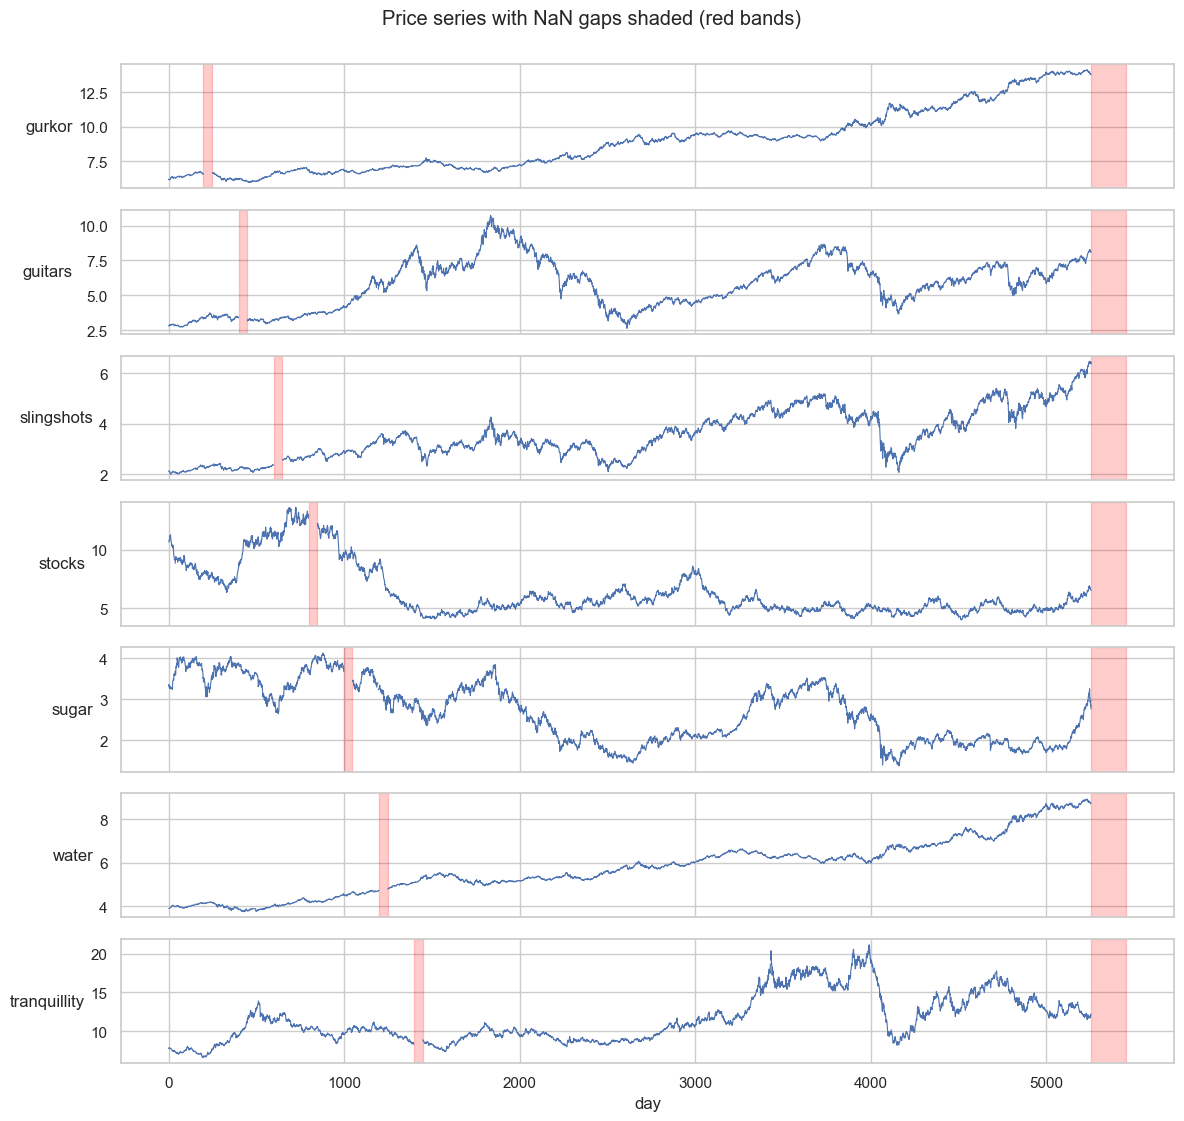

In [7]:
# Visualise gaps on top of the price series. Each series gets its own row;
# NaN stretches longer than a single day are shown as shaded bands.
MIN_GAP_HIGHLIGHT = 2  # don't shade isolated single-day NaNs

fig, axes = plt.subplots(len(series_cols), 1, figsize=(12, 1.6 * len(series_cols)),
                         sharex=True)
for ax, c in zip(axes, series_cols):
    ax.plot(df.index, df[c], lw=0.8)
    for start, end, length in find_nan_gaps(df[c]):
        if length >= MIN_GAP_HIGHLIGHT:
            ax.axvspan(start, end, color='red', alpha=0.20)
    ax.set_ylabel(c, rotation=0, ha='right', va='center')
axes[-1].set_xlabel('day')
fig.suptitle('Price series with NaN gaps shaded (red bands)', y=1.00)
fig.tight_layout()
plt.show()

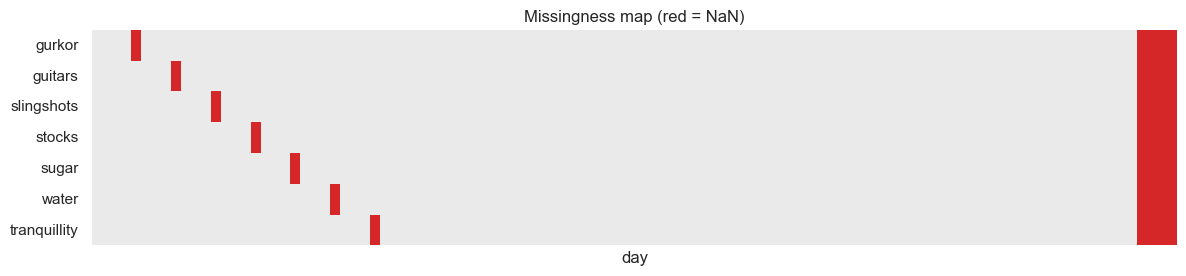

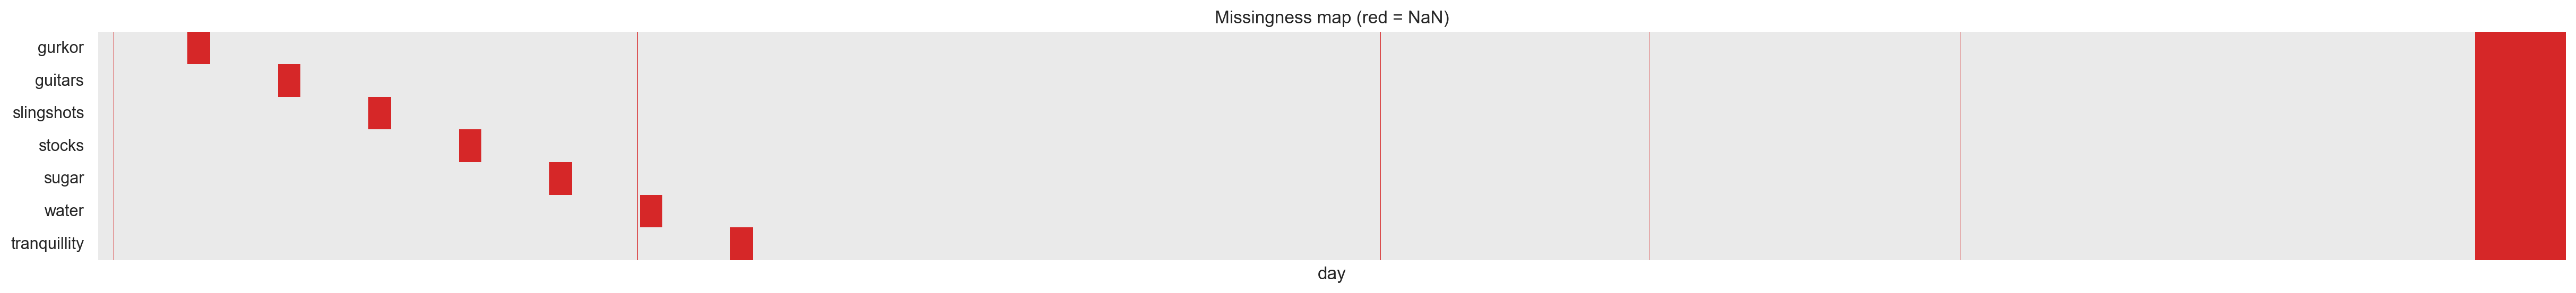

In [8]:
# Row-level missingness strip: a compact view of *where* each series is NaN.
missing = df[series_cols].isna().astype(int).T
fig, ax = plt.subplots(figsize=(14, 2.8))
sns.heatmap(missing, cbar=False, cmap=['#eaeaea', '#d62728'], ax=ax,
            xticklabels=False, yticklabels=series_cols)
ax.set_xlabel('day')
ax.set_title('Missingness map (red = NaN)')
plt.show()

# One day = one pixel to show the "1000" NaNs
fig, ax = plt.subplots(figsize=(30, 2.8), dpi=200)
sns.heatmap(missing, cbar=False, cmap=['#eaeaea', '#d62728'], ax=ax,
            xticklabels=False, yticklabels=series_cols)
ax.set_xlabel('day')
ax.set_title('Missingness map (red = NaN)')
plt.show()

### 2.3 Windowing decision

From the plots:

- The last NaN gap ends around day **1450** (we compute the exact boundary below).
- From that day onwards, **all** series are simultaneously observed.
- Before that day, each series has its own gap but also has long observable stretches.

**Plan:**

- `df_full` — the cleaned full panel, NaNs where appropriate. Used for per-series work (each series drops its own NaNs).
- `df_common` — the gap-free common window, used wherever rows must be aligned across series (correlation, VAR, PCA, Granger).

In [9]:
df_full = df.copy()

# Drop any trailing rows that are fully NaN for every series (padding at end of file).
df_full = df_full.loc[:df_full.dropna(how='all').index.max()]

# Define the "common window" using only *structural* NaN gaps (long runs), so that
# the 5 scattered 1000→NaN rows inside the observable region don't bias where the
# window starts. We then drop those few rows so the resulting panel is aligned.
MIN_STRUCTURAL_GAP = 2  # a gap must be at least this long to count as structural
last_structural_nan = {}
for c in series_cols:
    structural_end_days = [end for _, end, length in find_nan_gaps(df_full[c])
                           if length >= MIN_STRUCTURAL_GAP]
    last_structural_nan[c] = max(structural_end_days) if structural_end_days else df_full.index.min() - 1
last_structural_nan = pd.Series(last_structural_nan)
common_start = int(last_structural_nan.max()) + 1
df_common = df_full.loc[common_start:].dropna()

print('Last day of each series\' final structural NaN run:')
print(last_structural_nan.to_string())
print(f'\nFull panel: day {df_full.index.min()} → {df_full.index.max()} ({len(df_full)} rows)')
print(f'Common window start: day {common_start}')
print(f'Common window after dropping scattered 1000-NaN rows: '
      f'{df_common.index.min()} → {df_common.index.max()} '
      f'({len(df_common)} rows, {len(df_common) / len(df_full):.0%} of full panel)')


Last day of each series' final structural NaN run:
gurkor           248
guitars          448
slingshots       648
stocks           848
sugar           1048
water           1248
tranquillity    1448

Full panel: day 1 → 5256 (5256 rows)
Common window start: day 1449
Common window after dropping scattered 1000-NaN rows: 1449 → 5256 (3805 rows, 72% of full panel)


## 3. Price-level exploration

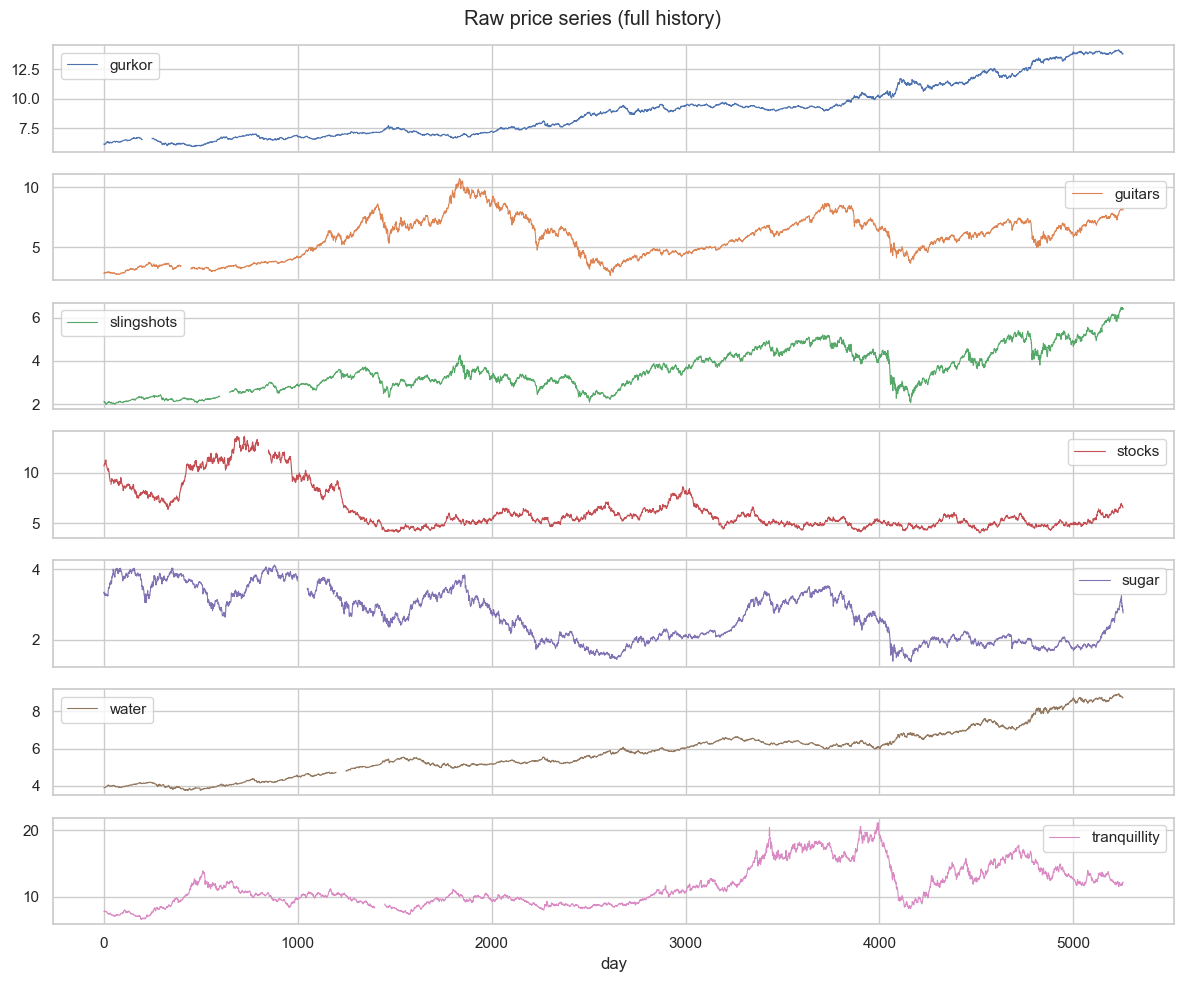

In [10]:
axes = df_full.plot(subplots=True, figsize=(12, 10), lw=0.8,
                    title='Raw price series (full history)')
plt.tight_layout()
plt.show()

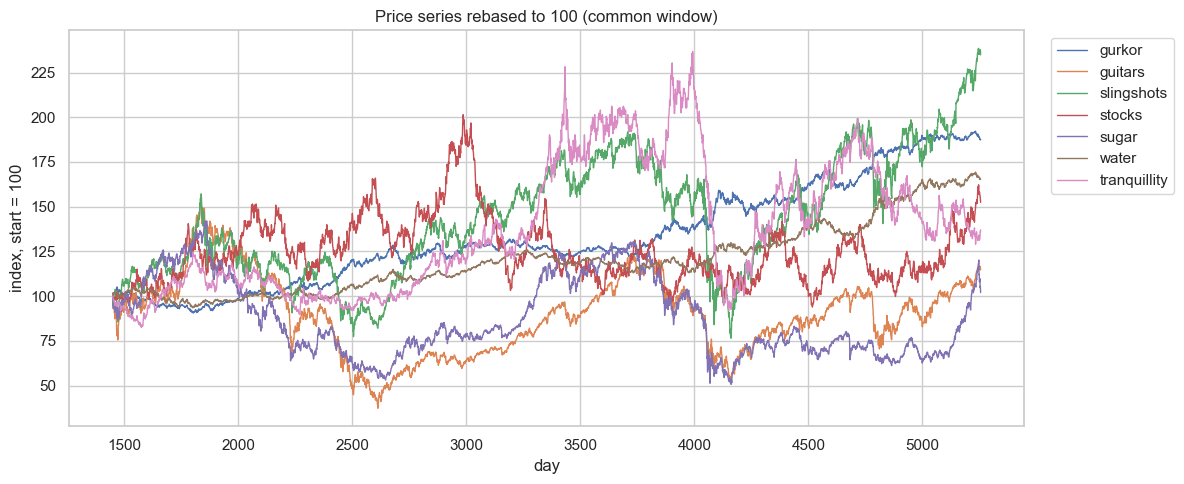

In [11]:
# Rebased to 100 on the first day of the common window → shapes comparable on one axis.
rebased = df_common.divide(df_common.iloc[0]).multiply(100)
fig, ax = plt.subplots(figsize=(12, 5))
rebased.plot(ax=ax, lw=1.0)
ax.set_title('Price series rebased to 100 (common window)')
ax.set_ylabel('index, start = 100')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Returns — univariate stylised facts

We use **log-returns** $r_t = \log(P_t / P_{t-1})$. Computed on "df_full" per series, so each series keeps all observations except where its own NaN gap breaks the difference.

In [12]:
log_ret_full = np.log(df_full / df_full.shift(1))
log_ret_common = np.log(df_common / df_common.shift(1)).dropna()
print(f'log_ret_full non-NaN counts per series:\n{log_ret_full.count().to_string()}')
print(f'\nlog_ret_common shape: {log_ret_common.shape}')

log_ret_full non-NaN counts per series:
gurkor          5194
guitars         5194
slingshots      5194
stocks          5194
sugar           5194
water           5194
tranquillity    5194

log_ret_common shape: (3804, 7)


In [13]:
# Summary statistics per series (computed on each series' own observed log-returns).
def summarise(r):
    r = r.dropna()
    return pd.Series({
        'n': len(r),
        'mean': r.mean(),
        'std': r.std(),
        'min': r.min(),
        'max': r.max(),
        'skew': stats.skew(r),
        'excess_kurt': stats.kurtosis(r),  # Fisher = excess
        'jarque_bera_p': stats.jarque_bera(r).pvalue,
    })

stats_tbl = log_ret_full.apply(summarise).T
stats_tbl.style.format({'n': '{:,.0f}', 'mean': '{:+.4f}', 'std': '{:.4f}',
                        'min': '{:+.3f}', 'max': '{:+.3f}', 'skew': '{:+.2f}',
                        'excess_kurt': '{:+.2f}', 'jarque_bera_p': '{:.1e}'})

,n,mean,std,min,max,skew,excess_kurt,jarque_bera_p
gurkor,"5,194",+0.0002,0.0039,-0.025,+0.036,-0.15,+3.51,0.0e+00
guitars,"5,194",+0.0002,0.0149,-0.093,+0.123,-0.03,+5.55,0.0e+00
slingshots,"5,194",+0.0002,0.0147,-0.122,+0.093,-0.44,+6.43,0.0e+00
stocks,"5,194",-0.0001,0.0149,-0.060,+0.052,-0.12,+0.08,6.8e-04
sugar,"5,194",-0.0000,0.0152,-0.141,+0.189,-0.24,+10.69,0.0e+00
water,"5,194",+0.0002,0.0035,-0.026,+0.017,-0.26,+2.25,1.3e-250
tranquillity,"5,194",+0.0001,0.0126,-0.087,+0.060,-0.27,+2.97,0.0e+00


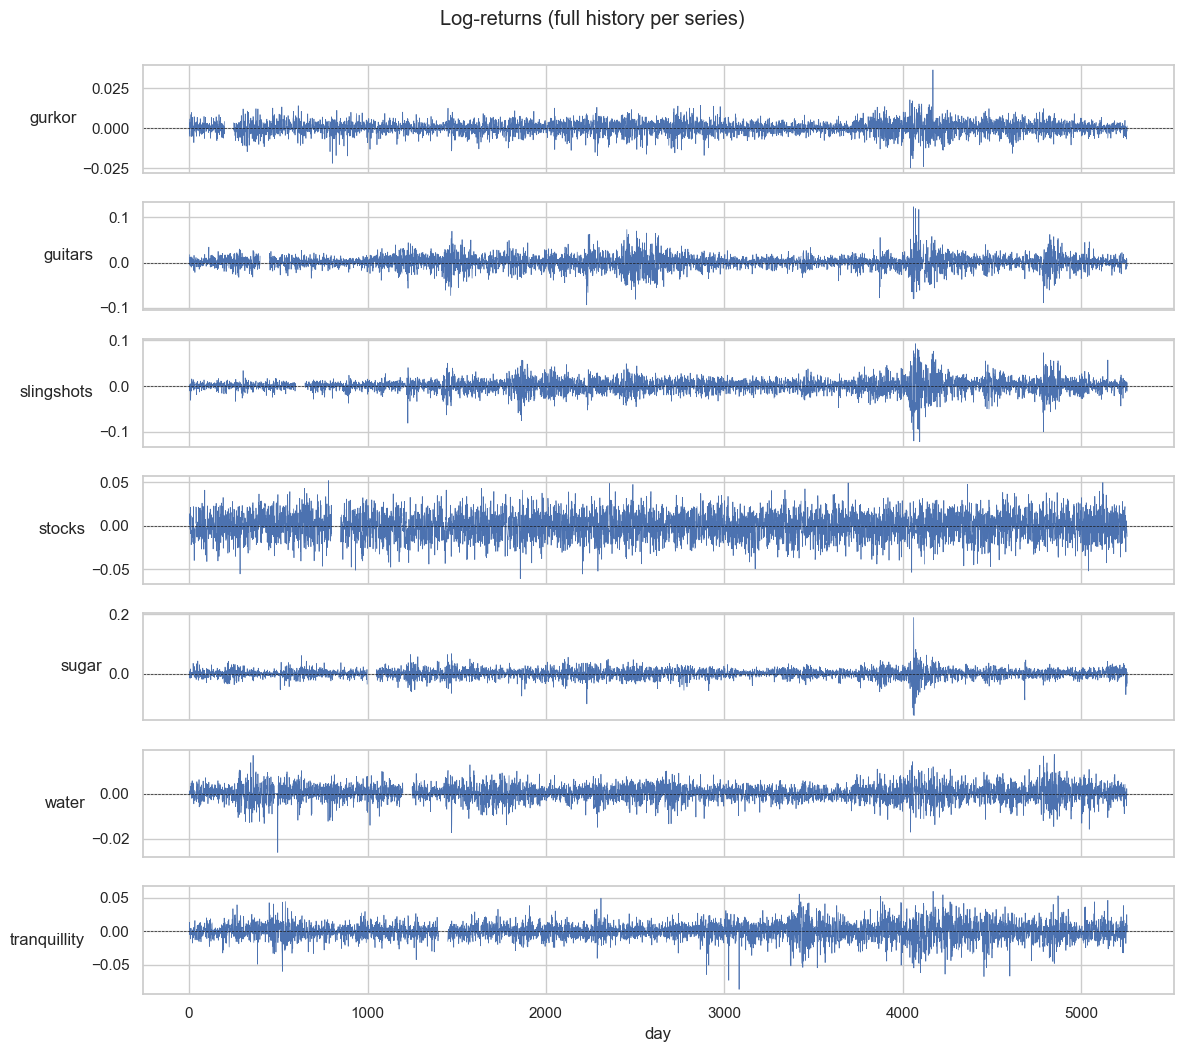

In [14]:
fig, axes = plt.subplots(len(series_cols), 1, figsize=(12, 1.5 * len(series_cols)),
                         sharex=True)
for ax, c in zip(axes, series_cols):
    ax.plot(log_ret_full.index, log_ret_full[c], lw=0.5)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_ylabel(c, rotation=0, ha='right', va='center')
axes[-1].set_xlabel('day')
fig.suptitle('Log-returns (full history per series)', y=1.00)
fig.tight_layout()
plt.show()

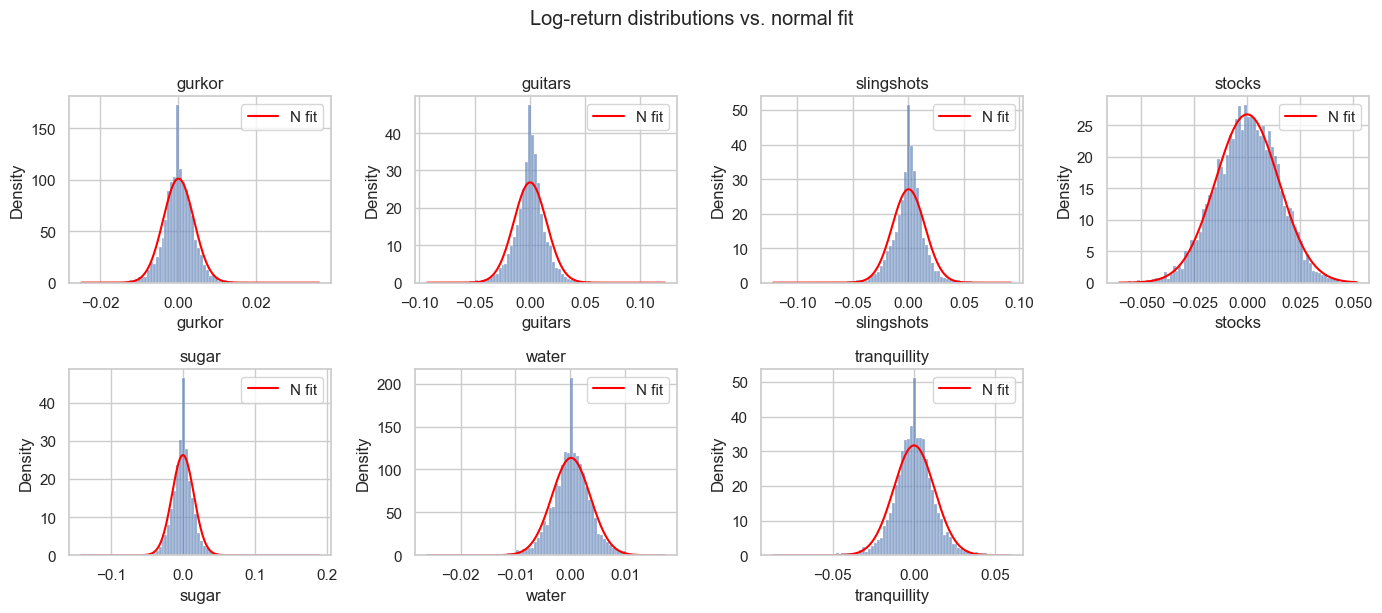

In [15]:
# Return distributions vs. normal overlay of matching mean/std. Heavy tails show up
# as mass beyond the bell curve.
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, c in zip(axes.flat, series_cols):
    r = log_ret_full[c].dropna()
    sns.histplot(r, bins=80, stat='density', ax=ax, alpha=0.6, edgecolor=None)
    xs = np.linspace(r.min(), r.max(), 300)
    ax.plot(xs, stats.norm.pdf(xs, r.mean(), r.std()), color='red', lw=1.5,
            label='N fit')
    ax.set_title(c)
    ax.legend()
axes.flat[-1].set_visible(False)
fig.suptitle('Log-return distributions vs. normal fit', y=1.02)
fig.tight_layout()
plt.show()

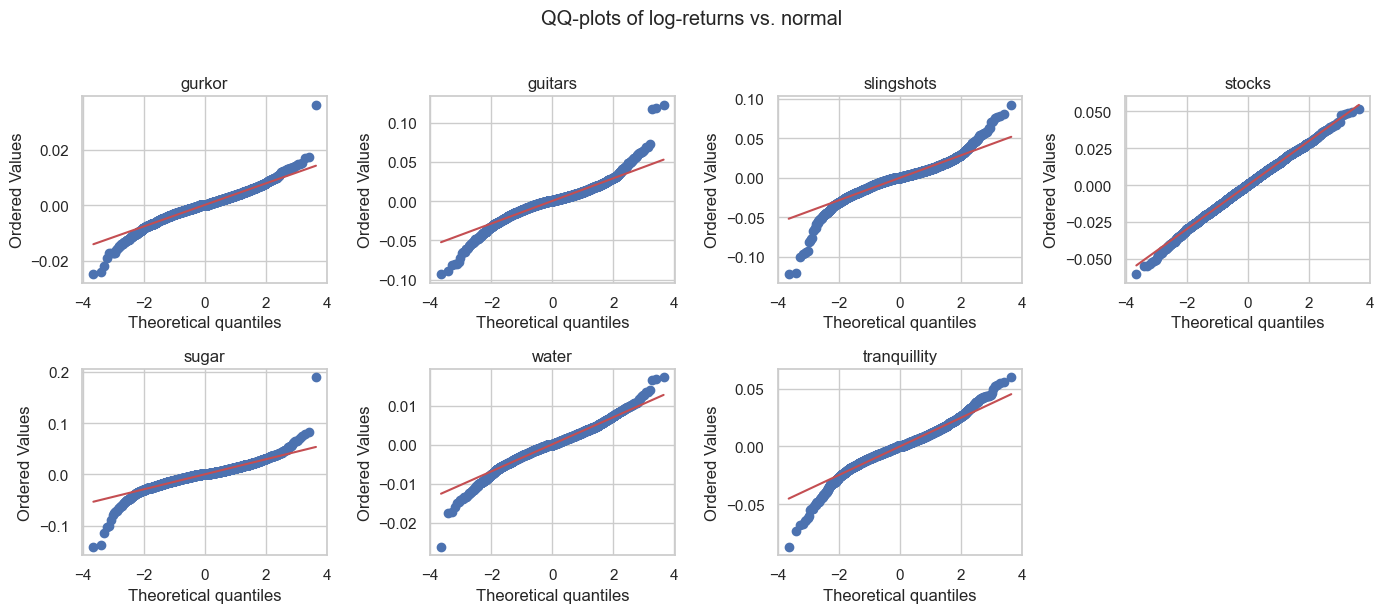

In [16]:
# QQ-plots vs. normal. A straight line = Gaussian; S-shape = heavy tails.
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, c in zip(axes.flat, series_cols):
    stats.probplot(log_ret_full[c].dropna(), dist='norm', plot=ax)
    ax.set_title(c)
axes.flat[-1].set_visible(False)
fig.suptitle('QQ-plots of log-returns vs. normal', y=1.02)
fig.tight_layout()
plt.show()

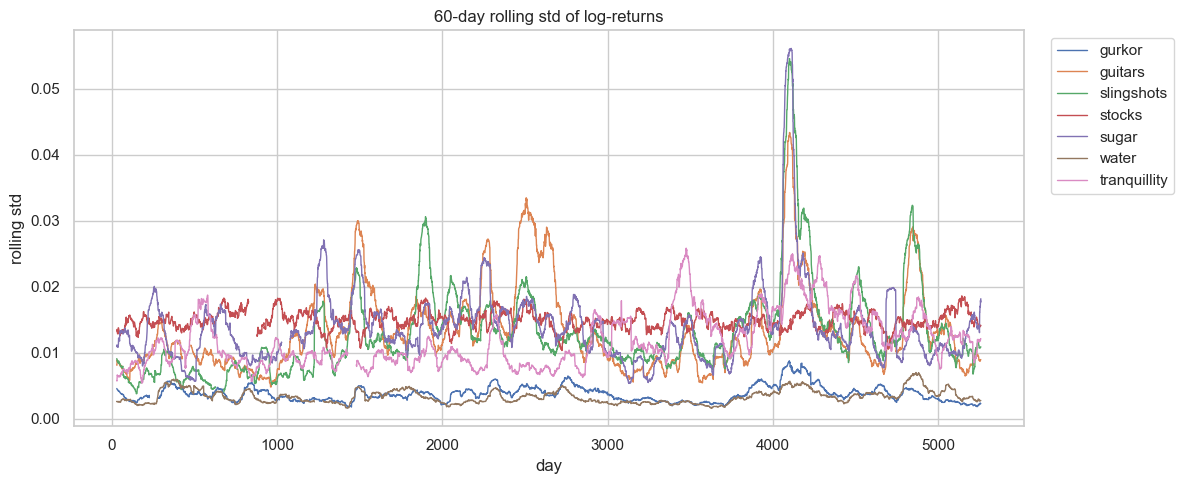

In [17]:
# Rolling 60-day volatility — volatility clustering / regime shifts.
roll_vol = log_ret_full.rolling(60, min_periods=30).std()
fig, ax = plt.subplots(figsize=(12, 5))
roll_vol.plot(ax=ax, lw=1.0)
ax.set_title('60-day rolling std of log-returns')
ax.set_ylabel('rolling std')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

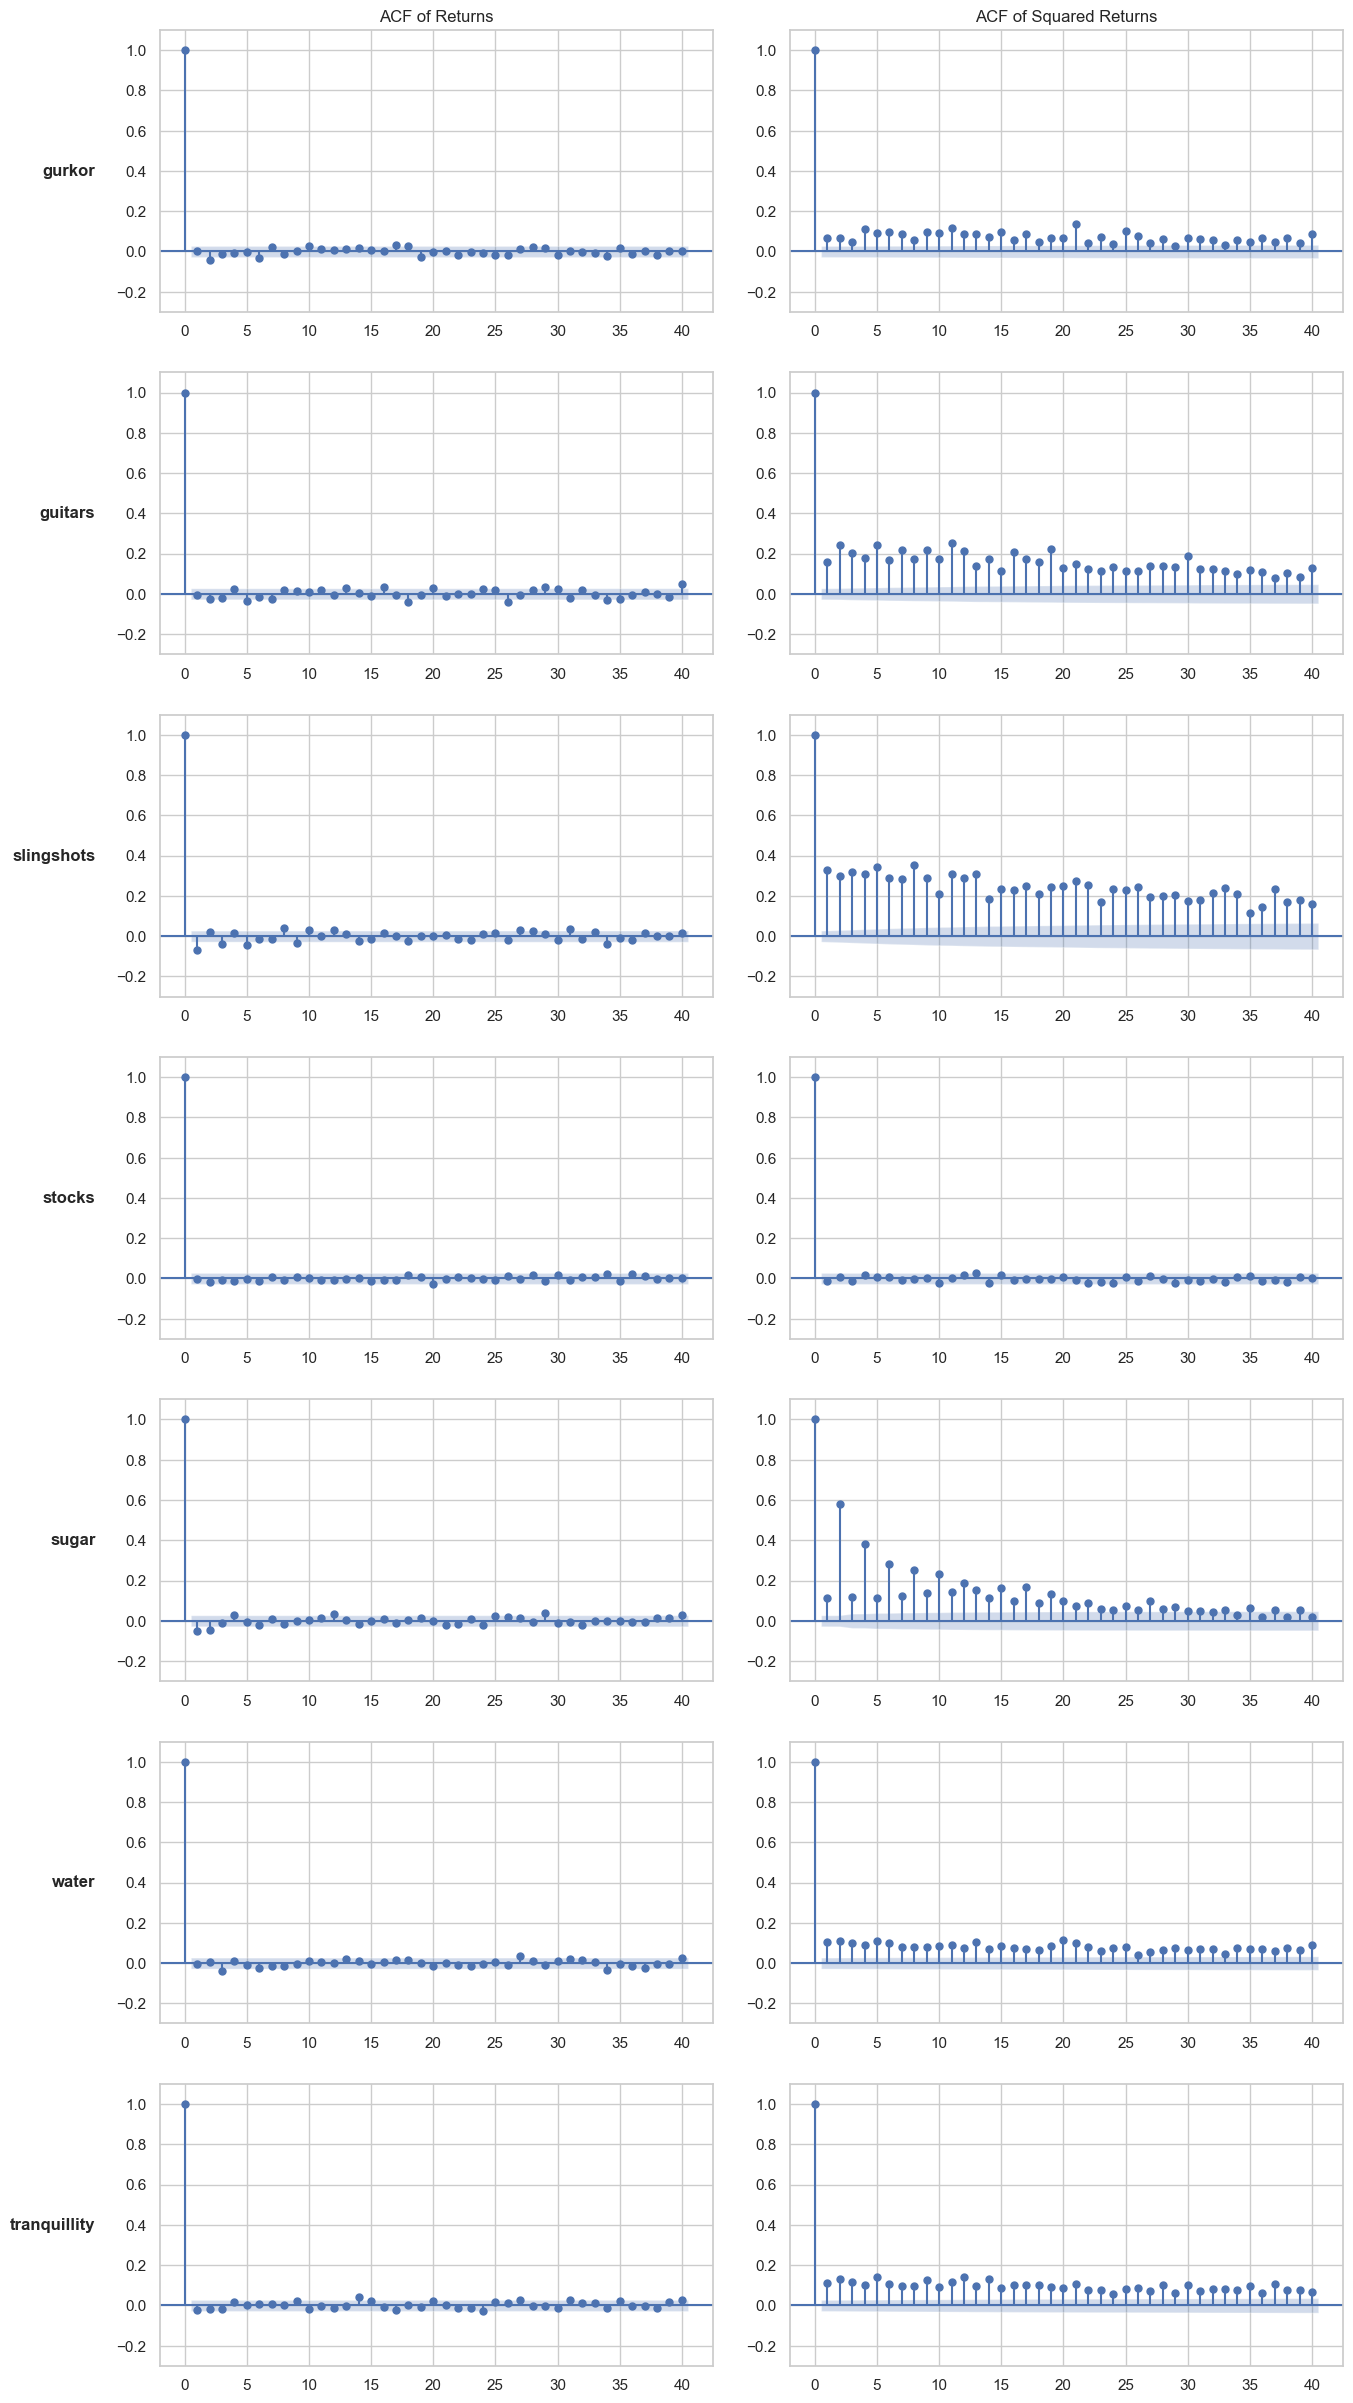

In [18]:
# ACF of returns and of squared returns. ACF of r_t ≈ 0 at most lags is expected
# for efficient price series; ACF of r_t^2 decaying slowly is the classic
# volatility-clustering signature (used later when motivating GARCH-type models).

fig, axes = plt.subplots(len(series_cols), 2, figsize=(14, 3.5 * len(series_cols)))

# Ensure axes is 2D even if there's only one series
if len(series_cols) == 1:
    axes = axes.reshape(1, -1)

for i, c in enumerate(series_cols):
    r = log_ret_full[c].dropna()
    plot_acf(r, lags=40, ax=axes[i, 0], title='')
    plot_acf(r ** 2, lags=40, ax=axes[i, 1], title='')

    # Set the y-axis limits to go from...
    axes[i, 0].set_ylim(-0.3, 1.1)
    axes[i, 1].set_ylim(-0.3, 1.1)
    
    # Improve y-label positioning so it doesn't overlap with the y-axis ticks
    axes[i, 0].set_ylabel(c, rotation=0, ha='right', va='center', labelpad=15, fontweight='bold')

axes[0, 0].set_title('ACF of Returns')
axes[0, 1].set_title('ACF of Squared Returns')



# Add padding to prevent title/axis overlapping
fig.tight_layout(pad=2.0)
plt.show()

In [19]:
# Augmented Dickey-Fuller test: p < 0.05 → reject unit root → series is stationary.
# We expect log-returns to be stationary; prices (random walks) should not be.
def adf_row(s):
    s = s.dropna()
    stat, p, *_ = adfuller(s)
    return pd.Series({'adf_stat': stat, 'p_value': p, 'stationary @ 5%': p < 0.05})

adf_prices = df_full.apply(adf_row).T
adf_returns = log_ret_full.apply(adf_row).T
print('ADF on prices:')
print(adf_prices.round(4))
print('\nADF on log-returns:')
print(adf_returns.round(4))

ADF on prices:
              adf_stat   p_value stationary @ 5%
gurkor        0.734652  0.990505           False
guitars      -2.051224  0.264574           False
slingshots    -0.92292  0.780331           False
stocks       -2.300647  0.171759           False
sugar        -1.921775  0.321888           False
water         0.787063  0.991424           False
tranquillity -2.241194  0.191635           False

ADF on log-returns:
               adf_stat p_value stationary @ 5%
gurkor       -53.188507     0.0            True
guitars      -12.185307     0.0            True
slingshots   -19.114756     0.0            True
stocks       -72.120614     0.0            True
sugar        -36.804794     0.0            True
water        -43.152627     0.0            True
tranquillity -73.566715     0.0            True


## 5. Cross-sectional relationships

From here on, all analysis uses `log_ret_common` so rows are aligned across series.

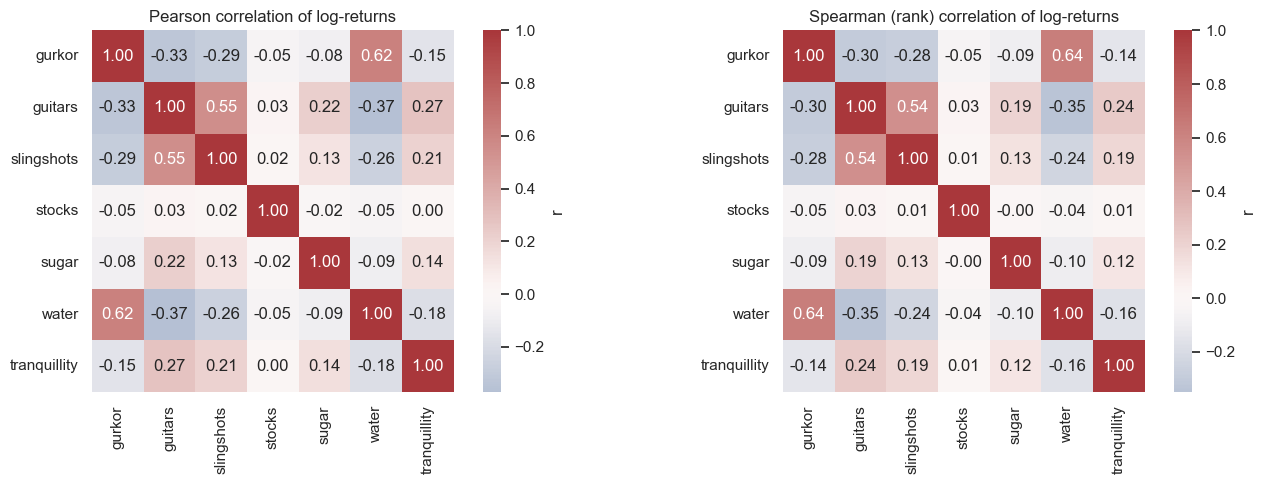

In [20]:
# Pearson (linear) and Spearman (rank) correlation. Spearman is robust to heavy tails.
corr_p = log_ret_common.corr(method='pearson')
corr_s = log_ret_common.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_p, annot=True, fmt='.2f', cmap='vlag', center=0, ax=axes[0],
            cbar_kws={'label': 'r'}, square=True)
axes[0].set_title('Pearson correlation of log-returns')
sns.heatmap(corr_s, annot=True, fmt='.2f', cmap='vlag', center=0, ax=axes[1],
            cbar_kws={'label': 'r'}, square=True)
axes[1].set_title('Spearman (rank) correlation of log-returns')
plt.tight_layout()
plt.show()

VAR selected k = 3 lags by AIC


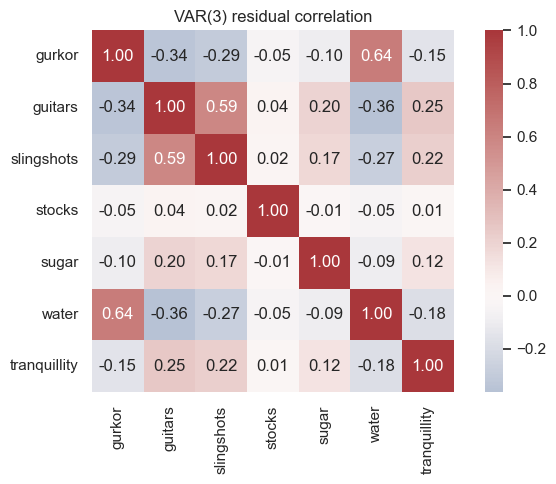

In [21]:
# VAR residual correlation = "simultaneous" co-movement after stripping out
# everything one series' history predicts about another's. If the VAR captures
# the lagged dynamics well, this residual correlation is the cleaner measure
# of contemporaneous dependence than raw corr on r_t.
var_model = VAR(log_ret_common).fit(maxlags=7, ic='aic')
print(f'VAR selected k = {var_model.k_ar} lags by AIC')
res_corr = var_model.resid.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(res_corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax,
            square=True)
ax.set_title(f'VAR({var_model.k_ar}) residual correlation')
plt.tight_layout()
plt.show()

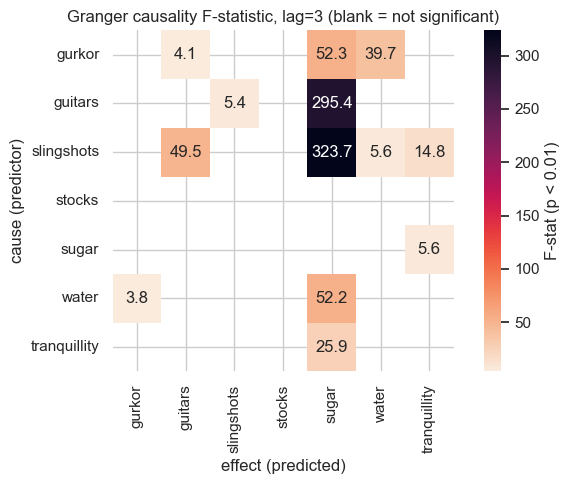

In [22]:
# Granger causality F-stat heatmap at lag 3. Row → column means "row's past helps
# predict column beyond column's own past." Cells masked where p > threshold.
LAG = 3
P_THRESH = 0.01
cols = log_ret_common.columns
F = pd.DataFrame(np.nan, index=cols, columns=cols)
P = pd.DataFrame(np.nan, index=cols, columns=cols)
for cause in cols:
    for effect in cols:
        if cause == effect:
            continue
        pair = log_ret_common[[effect, cause]]
        res = grangercausalitytests(pair, maxlag=LAG, verbose=False)
        F.loc[cause, effect] = res[LAG][0]['ssr_ftest'][0]
        P.loc[cause, effect] = res[LAG][0]['ssr_ftest'][1]

F_masked = F.where(P < P_THRESH)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(F_masked, annot=True, fmt='.1f', cmap='rocket_r', ax=ax, square=True,
            cbar_kws={'label': 'F-stat (p < {:.2f})'.format(P_THRESH)})
ax.set_xlabel('effect (predicted)')
ax.set_ylabel('cause (predictor)')
ax.set_title(f'Granger causality F-statistic, lag={LAG} (blank = not significant)')
plt.tight_layout()
plt.show()

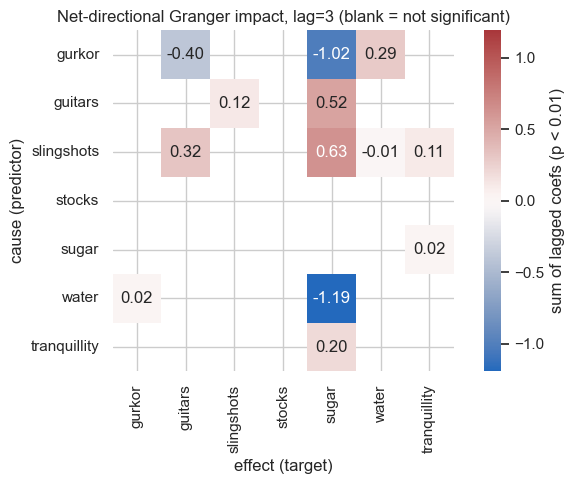

In [23]:
# Net-directional Granger: instead of the F-statistic, plot the sum of lagged
# predictor coefficients (significance-masked). Positive row→column means the
# predictor moves the target in the same direction; it identifies net
# transmitters vs. receivers of shocks in a way the F-stat picture cannot.
net_coef = pd.DataFrame(np.nan, index=cols, columns=cols)
p_net    = pd.DataFrame(np.nan, index=cols, columns=cols)
for predictor in cols:
    for target in cols:
        if predictor == target:
            continue
        pair = log_ret_common[[target, predictor]]
        res  = grangercausalitytests(pair, maxlag=LAG, verbose=False)
        p_net.loc[predictor, target] = res[LAG][0]['ssr_ftest'][1]
        # In statsmodels' unrestricted OLS, coefficients are ordered as
        # [target lags 1..L, predictor lags 1..L, const]. Sum the predictor
        # block to get the net lagged impact.
        unrestricted = res[LAG][1][1]
        predictor_coefs = unrestricted.params[LAG:2 * LAG]
        net_coef.loc[predictor, target] = predictor_coefs.sum()

net_masked = net_coef.where(p_net < P_THRESH)
vmax = np.nanmax(np.abs(net_masked.values))
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(net_masked, annot=True, fmt='.2f', cmap='vlag', center=0,
            vmin=-vmax, vmax=vmax, ax=ax, square=True,
            cbar_kws={'label': f'sum of lagged coefs (p < {P_THRESH:.2f})'})
ax.set_xlabel('effect (target)')
ax.set_ylabel('cause (predictor)')
ax.set_title(f'Net-directional Granger impact, lag={LAG} (blank = not significant)')
plt.tight_layout()
plt.show()


Granger persistence across lags 1..10 at p < 0.05
Top 15 predictor → target pairs by persistence:
   predictor       target  sig_lags  persistence
  slingshots      guitars        10          1.0
       water        sugar        10          1.0
tranquillity        sugar        10          1.0
      gurkor        sugar        10          1.0
      gurkor        water        10          1.0
     guitars   slingshots        10          1.0
     guitars        sugar        10          1.0
  slingshots tranquillity        10          1.0
  slingshots        water        10          1.0
  slingshots        sugar        10          1.0
       sugar tranquillity         9          0.9
       water       gurkor         8          0.8
       sugar        water         7          0.7
       sugar       gurkor         6          0.6
      gurkor      guitars         6          0.6


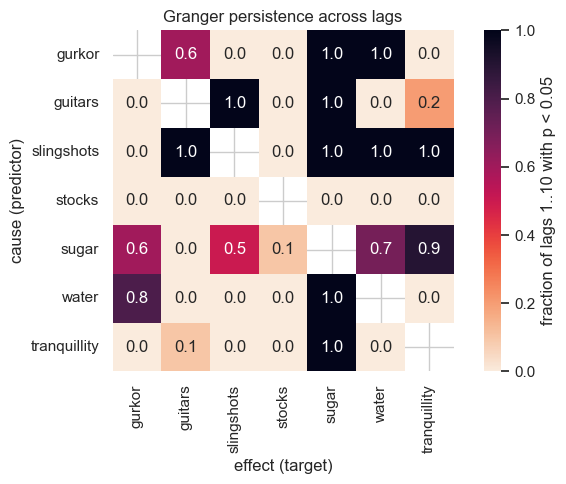

In [24]:
# Persistence check: for each pair, count how many lags (1..MAX_LAG) give a
# significant Granger test. Edges that survive most lags are more robust than
# those that are significant at one lag only.
MAX_LAG = 10
P_PERSIST = 0.05
records = []
for predictor in cols:
    for target in cols:
        if predictor == target:
            continue
        pair = log_ret_common[[target, predictor]]
        gc = grangercausalitytests(pair, maxlag=MAX_LAG, verbose=False)
        sig = sum(gc[l][0]['ssr_ftest'][1] < P_PERSIST for l in range(1, MAX_LAG + 1))
        records.append({'predictor': predictor, 'target': target,
                        'sig_lags': sig, 'persistence': sig / MAX_LAG})
persist_df = pd.DataFrame(records).sort_values('persistence', ascending=False)
print(f'Granger persistence across lags 1..{MAX_LAG} at p < {P_PERSIST}')
print(f'Top 15 predictor → target pairs by persistence:')
print(persist_df.head(15).to_string(index=False))

# Same info as a heatmap: fraction of lags significant.
persist_mat = persist_df.pivot(index='predictor', columns='target',
                               values='persistence').reindex(index=cols, columns=cols)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(persist_mat, annot=True, fmt='.1f', cmap='rocket_r', ax=ax,
            square=True, vmin=0, vmax=1,
            cbar_kws={'label': f'fraction of lags 1..{MAX_LAG} with p < {P_PERSIST}'})
ax.set_xlabel('effect (target)')
ax.set_ylabel('cause (predictor)')
ax.set_title('Granger persistence across lags')
plt.tight_layout()
plt.show()


### 5.1 Volatility correlation structure

The Pearson/Spearman heatmaps above measure co-movement of **returns**. A separate question is whether the **volatilities** themselves co-move — i.e. whether high-vol days for one series tend to coincide with high-vol days for another. This is what a CCC/DCC-GARCH model would care about, and it can be very different from the level correlation: e.g. `stocks` may have ~zero return correlation with the commodities yet share their volatility regimes.

Three quick proxies, all on `log_ret_common`:

1. **Squared-returns correlation**: $\mathrm{corr}(r_{i,t}^2, r_{j,t}^2)$ — contemporaneous vol co-movement.
2. **Abs-returns correlation**: $\mathrm{corr}(|r_{i,t}|, |r_{j,t}|)$ — same idea, more robust to outliers.
3. **Rolling-vol correlation**: correlation of 30-day rolling std across series — captures slower regime co-movement.

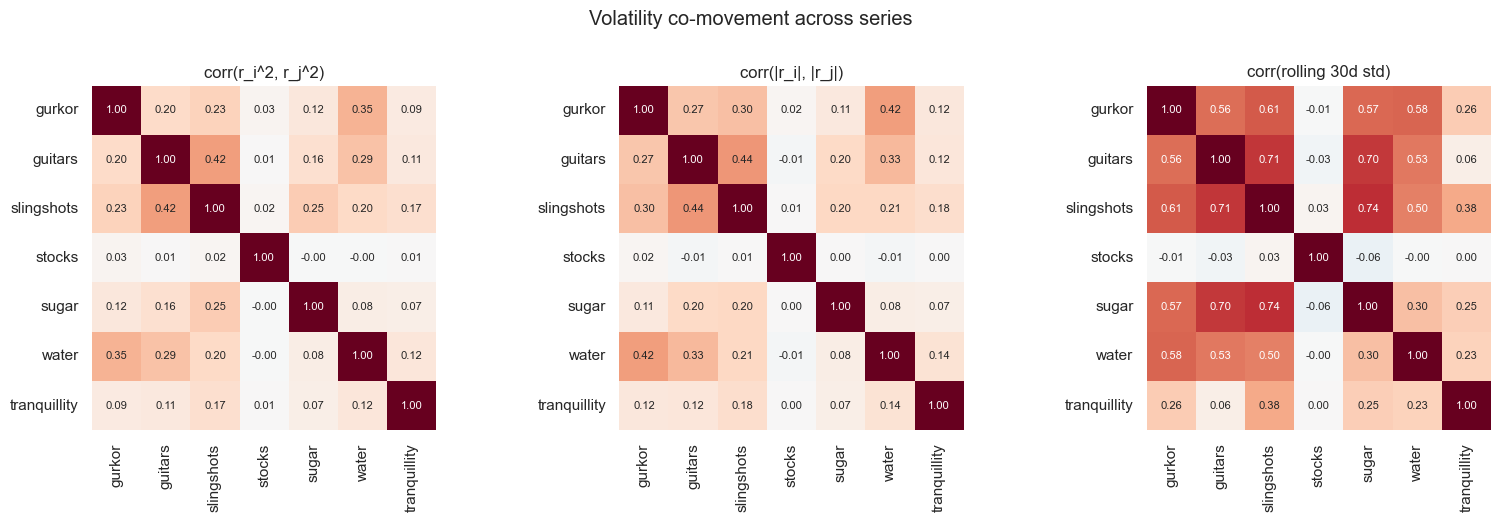

Off-diagonal:  vol-correlation  minus  return-correlation
(positive => more vol co-movement than level co-movement)

                           corr(r_i^2, r_j^2)  corr(|r_i|, |r_j|)  corr(rolling 30d std)
guitars      water                      0.664               0.699                  0.897
gurkor       guitars                    0.526               0.602                  0.890
             slingshots                 0.520               0.596                  0.902
slingshots   water                      0.464               0.467                  0.762
water        tranquillity               0.301               0.324                  0.414
gurkor       tranquillity               0.241               0.266                  0.407
             sugar                      0.197               0.187                  0.651
sugar        water                      0.168               0.169                  0.396
slingshots   sugar                      0.126               0.079                 

In [25]:
# Three views of volatility co-movement on the aligned common window.
sq   = log_ret_common ** 2
absr = log_ret_common.abs()
roll = log_ret_common.rolling(30).std().dropna()

vol_corrs = {
    'corr(r_i^2, r_j^2)':       sq.corr(),
    'corr(|r_i|, |r_j|)':       absr.corr(),
    'corr(rolling 30d std)':    roll.corr(),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, M) in zip(axes, vol_corrs.items()):
    sns.heatmap(M, ax=ax, vmin=-0.2, vmax=1.0, cmap='RdBu_r', center=0,
                annot=True, fmt='.2f', cbar=False, square=True,
                xticklabels=M.columns, yticklabels=M.index, annot_kws={'size': 8})
    ax.set_title(title)
fig.suptitle('Volatility co-movement across series', y=1.02)
plt.tight_layout(); plt.show()

# Compare each volatility-correlation matrix to the plain return-correlation
# matrix. Pairs where vol-corr >> return-corr have shared volatility regimes
# without shared directional moves — exactly the channel CCC carries and a
# linear regression on returns misses.
return_corr = log_ret_common.corr()
diffs = []
for name, M in vol_corrs.items():
    d = (M - return_corr).where(np.triu(np.ones_like(M, dtype=bool), k=1)).stack()
    d.name = name
    diffs.append(d)
diff_tbl = pd.concat(diffs, axis=1).round(3)
print('Off-diagonal:  vol-correlation  minus  return-correlation')
print('(positive => more vol co-movement than level co-movement)\n')
print(diff_tbl.sort_values(diff_tbl.columns[0], ascending=False).to_string())

# Spotlight on stocks: how does it sit vs the commodities under each measure?
print('\nStocks row across measures:')
spot = pd.DataFrame({
    'return_corr':       return_corr['stocks'],
    'sq_returns_corr':   vol_corrs['corr(r_i^2, r_j^2)']['stocks'],
    'abs_returns_corr':  vol_corrs['corr(|r_i|, |r_j|)']['stocks'],
    'rolling_vol_corr':  vol_corrs['corr(rolling 30d std)']['stocks'],
}).drop('stocks').round(3)
print(spot.to_string())

### 5.2 Conditional volatility correlation

The matrices in 5.1 mix two effects: (i) genuine cross-series vol co-movement and (ii) shared mean dynamics via the VAR — if `r_{i,t}` and `r_{j,t}` are linearly predictable from common lagged information, even a constant-vol world produces some `corr(r_i^2, r_j^2) > 0`.

To isolate the volatility channel we strip the mean dynamics first:

1. Fit **VAR(2)** on `log_ret_common`.
2. Look at residual co-movement: `corr(e_i^2, e_j^2)` and `corr(|e_i|, |e_j|)`. VAR only models the conditional **mean**, never the variance — vol clustering and cross-vol structure pass through into `e_t` untouched, so this is *not* double-counting.
3. Fit **GARCH(1,1)** per residual to get conditional volatilities `σ_{i,t}`, then plot `corr(σ_{i,t}, σ_{j,t})` — direct conditional-vol co-movement.
4. **Standardised residuals** `z_{i,t} = e_{i,t}/σ_{i,t}` should have weak vol structure if the univariate GARCHes captured it; their `corr(|z_i|, |z_j|)` is therefore a residual-vol-correlation diagnostic — large off-diagonals there mean a univariate-GARCH-per-series model is leaving multivariate vol structure on the table (motivating DCC/BEKK).

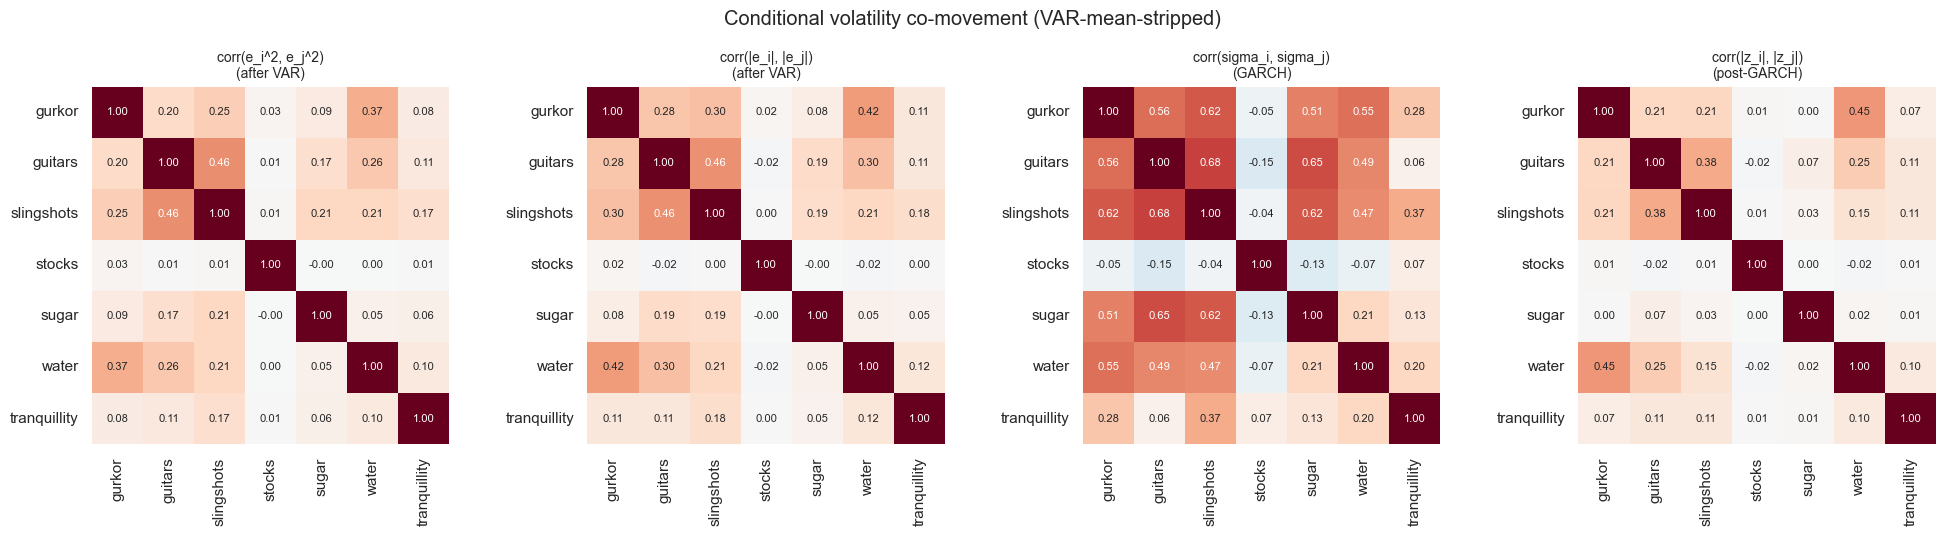


GARCH conditional-vol correlation MINUS return correlation (off-diagonal):
gurkor        slingshots      0.909
              guitars         0.887
guitars       water           0.864
slingshots    water           0.734
gurkor        sugar           0.587
slingshots    sugar           0.495
guitars       sugar           0.432
gurkor        tranquillity    0.426
water         tranquillity    0.385
sugar         water           0.302
slingshots    tranquillity    0.157
guitars       slingshots      0.127
stocks        tranquillity    0.071
gurkor        stocks         -0.001
sugar         tranquillity   -0.012
stocks        water          -0.017
slingshots    stocks         -0.057
gurkor        water          -0.074
stocks        sugar          -0.109
guitars       stocks         -0.182
              tranquillity   -0.214
gurkor        gurkor            NaN
guitars       gurkor            NaN
              guitars           NaN
slingshots    gurkor            NaN
              guitars   

In [32]:
from statsmodels.tsa.api import VAR
from arch import arch_model

# 1. VAR(2) residuals on the aligned panel ---------------------------------
var_lag = 2
var_res = VAR(log_ret_common).fit(var_lag)
e = pd.DataFrame(np.asarray(var_res.resid),
                 index=log_ret_common.index[var_lag:],
                 columns=series_cols)

# 2. Univariate GARCH(1,1) per residual -> conditional vols ----------------
sigma = pd.DataFrame(index=e.index, columns=series_cols, dtype=float)
for c in series_cols:
    gf = arch_model(e[c].values * 100000, mean='Zero', vol='GARCH',
                    p=1, q=1, dist='normal').fit(disp='off')
    sigma[c] = gf.conditional_volatility / 100000.0

# 3. Standardised residuals ------------------------------------------------
z = e / sigma

# 4. Build the four conditional vol-correlation views ---------------------
cond_corrs = {
    'corr(e_i^2, e_j^2)\n(after VAR)':   (e ** 2).corr(),
    'corr(|e_i|, |e_j|)\n(after VAR)':   e.abs().corr(),
    'corr(sigma_i, sigma_j)\n(GARCH)':   sigma.corr(),
    'corr(|z_i|, |z_j|)\n(post-GARCH)':  z.abs().corr(),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, M) in zip(axes, cond_corrs.items()):
    sns.heatmap(M, ax=ax, vmin=-0.2, vmax=1.0, cmap='RdBu_r', center=0,
                annot=True, fmt='.2f', cbar=False, square=True,
                annot_kws={'size': 8})
    ax.set_title(title, fontsize=10)
fig.suptitle('Conditional volatility co-movement (VAR-mean-stripped)', y=1.02)
plt.tight_layout(); plt.show()

# Compare GARCH-vol correlation to the raw return correlation
print('\nGARCH conditional-vol correlation MINUS return correlation (off-diagonal):')
diff = (sigma.corr() - log_ret_common.corr()).where(
    np.triu(np.ones((len(series_cols),)*2, dtype=bool), k=1)).stack().round(3)
print(diff.sort_values(ascending=False).to_string())

# Stocks spotlight under all four measures
print('\nStocks row across conditional measures:')
spot = pd.DataFrame({
    'return_corr':         log_ret_common.corr()['stocks'],
    'corr(e^2)':           cond_corrs['corr(e_i^2, e_j^2)\n(after VAR)']['stocks'],
    'corr(|e|)':           cond_corrs['corr(|e_i|, |e_j|)\n(after VAR)']['stocks'],
    'corr(sigma)':         cond_corrs['corr(sigma_i, sigma_j)\n(GARCH)']['stocks'],
    'corr(|z|) post-GARCH': cond_corrs['corr(|z_i|, |z_j|)\n(post-GARCH)']['stocks'],
}).drop('stocks').round(3)
print(spot.to_string())

# CCC sanity check
print('\nCCC matrix (corr of standardized residuals z_t):')
print(z.corr().round(3).to_string())

## 6. PCA — can we group the series?

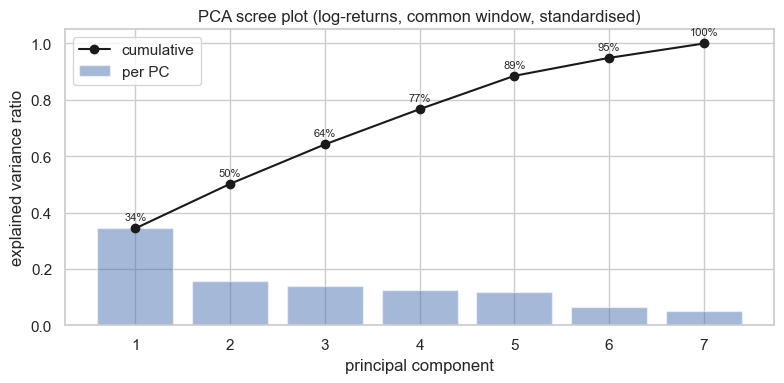

In [27]:
scaler = StandardScaler()
scaled = scaler.fit_transform(log_ret_common)
pca = PCA().fit(scaled)
expl = pca.explained_variance_ratio_
cum = expl.cumsum()

fig, ax = plt.subplots(figsize=(8, 4))
xs = np.arange(1, len(expl) + 1)
ax.bar(xs, expl, alpha=0.5, label='per PC')
ax.plot(xs, cum, marker='o', color='k', label='cumulative')
ax.set_xlabel('principal component')
ax.set_ylabel('explained variance ratio')
ax.set_title('PCA scree plot (log-returns, common window, standardised)')
ax.legend()
for x, c in zip(xs, cum):
    ax.annotate(f'{c:.0%}', (x, c), textcoords='offset points', xytext=(0, 6),
                ha='center', fontsize=8)
plt.tight_layout()
plt.show()

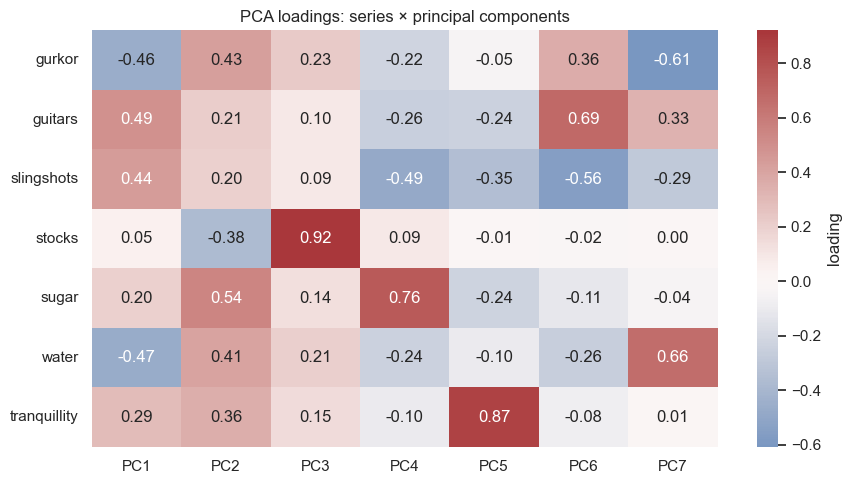

=== Top drivers per PC (|loading| > 0.3) ===

PC1  (explains 34.4%):
  guitars        + +0.494
  water          - -0.470
  gurkor         - -0.460
  slingshots     + +0.441

PC2  (explains 15.8%):
  sugar          + +0.544
  gurkor         + +0.431
  water          + +0.406
  stocks         - -0.377
  tranquillity   + +0.357

PC3  (explains 14.0%):
  stocks         + +0.921


In [28]:
loadings = pd.DataFrame(pca.components_.T,
                        index=log_ret_common.columns,
                        columns=[f'PC{i+1}' for i in range(pca.n_components_)])

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax,
            cbar_kws={'label': 'loading'})
ax.set_title('PCA loadings: series × principal components')
plt.tight_layout()
plt.show()

print('=== Top drivers per PC (|loading| > 0.3) ===')
for pc in loadings.columns[:3]:
    print(f'\n{pc}  (explains {expl[int(pc[2:]) - 1]:.1%}):')
    top = loadings[pc].reindex(loadings[pc].abs().sort_values(ascending=False).index)
    for feat, w in top.items():
        if abs(w) > 0.3:
            sign = '+' if w > 0 else '-'
            print(f'  {feat:<14} {sign} {w:+.3f}')

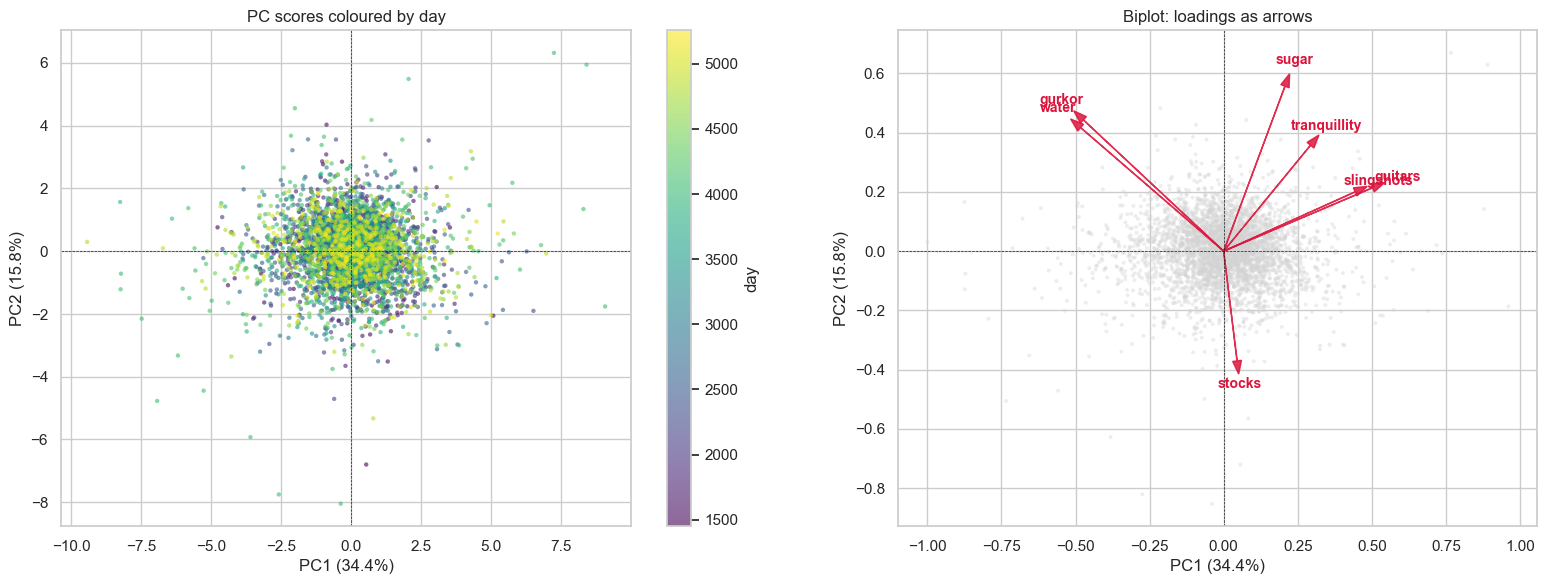

In [29]:
# PCA biplot: scores coloured by day (reveals drift/regime structure) with
# feature loadings drawn as arrows. Two things in one chart:
#   - scatter of observations in PC1/PC2 space, coloured by time → look for
#     temporal clusters or drift;
#   - arrows show which original series pull each PC → an intuitive alternative
#     to the loadings heatmap.
scores = pd.DataFrame(pca.transform(scaled)[:, :2],
                      index=log_ret_common.index, columns=['PC1', 'PC2'])
v1, v2 = expl[0] * 100, expl[1] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: scores coloured by day.
ax = axes[0]
sc = ax.scatter(scores['PC1'], scores['PC2'], c=scores.index, cmap='viridis',
                s=10, alpha=0.6, edgecolor='none')
ax.axhline(0, color='k', lw=0.5, ls='--'); ax.axvline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel(f'PC1 ({v1:.1f}%)'); ax.set_ylabel(f'PC2 ({v2:.1f}%)')
ax.set_title('PC scores coloured by day')
plt.colorbar(sc, ax=ax, label='day')

# Right: biplot (scaled scores + loading arrows).
ax = axes[1]
# Scale scores so they fill roughly the same range as the unit-ish loadings.
score_scale = max(scores['PC1'].abs().max(), scores['PC2'].abs().max())
ax.scatter(scores['PC1'] / score_scale, scores['PC2'] / score_scale,
           c='lightgrey', s=8, alpha=0.4, edgecolor='none')
arrow_scale = 1.1  # make arrows visible over the cloud
for feat in loadings.index:
    x, y = loadings.loc[feat, 'PC1'] * arrow_scale, loadings.loc[feat, 'PC2'] * arrow_scale
    ax.arrow(0, 0, x, y, head_width=0.03, length_includes_head=True,
             color='crimson', alpha=0.85)
    ax.text(x * 1.08, y * 1.08, feat, color='crimson', fontsize=10, ha='center',
            va='center', fontweight='bold')
ax.axhline(0, color='k', lw=0.5, ls='--'); ax.axvline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel(f'PC1 ({v1:.1f}%)'); ax.set_ylabel(f'PC2 ({v2:.1f}%)')
ax.set_title('Biplot: loadings as arrows')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


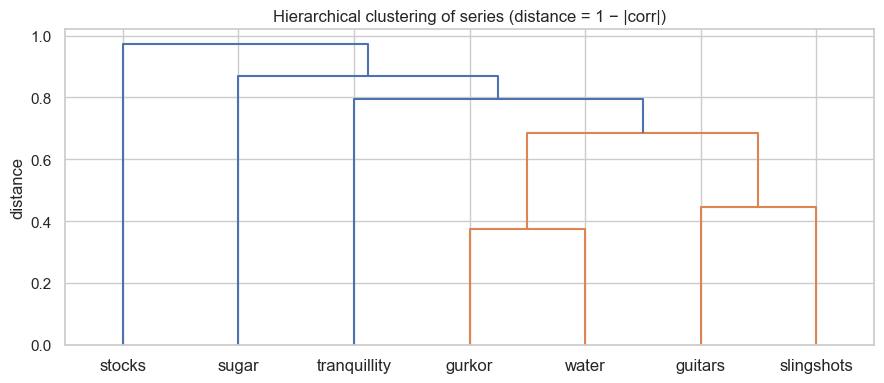

In [30]:
# Hierarchical clustering on 1 - |correlation| as a second view of grouping.
dist = 1 - corr_p.abs()
link = hierarchy.linkage(squareform(dist.values, checks=False), method='average')

fig, ax = plt.subplots(figsize=(9, 4))
hierarchy.dendrogram(link, labels=corr_p.columns.tolist(), ax=ax,
                     color_threshold=0.7)
ax.set_title('Hierarchical clustering of series (distance = 1 − |corr|)')
ax.set_ylabel('distance')
plt.tight_layout()
plt.show()

## 7. Summary of findings


**Data quality.** ...

**Univariate stylised facts.**
- ...

**Cross-sectional relationships.**
- ...



Pattern: These patterns are all analysed without the five values of 1000 in each time series. 

Gurkor

The time series Gurkor stands out from the rest of the time series by being the on strongest following a trend (rising steadily from 6.2 to 13.5 over the full time), seen in the Raw price series. From log-returns (full history per series) we can see that Gurkor has one of the smallest amplitudes of all the series, ranging only to 0.025 at its peak. The rolling std-deviation graf of log-returns stay consistently close to zero, with only on deviation from this at day 4100 where it reaches an amplitude of 0.055. From the table we can see that log-returns of Gurkor shows a excess kurtosis of  3.51, thus that the distribution Gurkor is pointier with larger tails. Lastly the ACF of squared returns shows only a small GARCH effect for the time series, showing that there is no great volatility clustering in the time series.


Guitars

The time series Guitars follows a strongly non-linear path, rising from around 2.8 to a peak near 10 around day 2500, before crashing sharply back to approximately 2.5 and partially recovering to 7.5. From the log-returns graph we can see clear volatility clustering, with the largest amplitudes concentrated around days 2000–3000 and again near day 4100, where returns reach close to ±0.1. The rolling standard deviation confirms this, showing several peaks between 0.025 and 0.033, making guitars one of the more volatile series outside of shock events. From the table, the excess kurtosis of 5.55 indicates a pointy distribution with heavy tails in both directions, consistent with what is visible in the QQ-plot where both tails deviate substantially from the normal line. The ACF of squared returns shows strong and persistent autocorrelation of around 0.20–0.25 across nearly all 40 lags, representing the second strongest GARCH signal in the dataset and indicating pronounced volatility clustering.

Slingshots

The time series Slingshots starts relatively flat before entering a rising trend, interrupted by a dramatic crash to near its starting value around day 3900–4000, followed by a rapid recovery to a new high of around 6.3. Despite ending with the highest rebased return of all series, the path there is the most turbulent. From the log-returns graph, volatility clustering is clearly visible, with the largest spikes concentrated around day 4000 reaching close to ±0.1. The rolling standard deviation shows recurring peaks of 0.020–0.030 throughout the period. From the table, slingshots carries an excess kurtosis of 6.43 and the most negative skewness of all series at −0.44, reflecting a heavier left tail and a greater tendency for large negative returns than positive ones. The ACF of squared returns is the strongest in the entire dataset, consistently around 0.30–0.35 across all 40 lags, indicating a highly persistent volatility process and strong volatility clustering.

Stocks

The time series Stocks is the only series with a predominantly negative long-term trend, falling from around 11 to 4.5 during the first 1500 days before levelling off at a low level. From the log-returns graph, stocks is visually distinct in that its amplitude is relatively modest at ±0.05 and evenly distributed across the entire period with no visible clustering, making it the most homogeneous of all series. The rolling standard deviation confirms this, remaining stable between 0.013 and 0.018 throughout without the dramatic peaks seen in other series. From the table, stocks has an excess kurtosis of just 0.08, nearly zero and unique in this dataset, meaning its return distribution is closer to normal than any other series, as clearly visible in the QQ-plot where points follow the reference line remarkably well. The ACF of both returns and squared returns is essentially white noise, with all lags falling within the confidence interval, a property unique to stocks and indicating a complete absence of volatility clustering.

Sugar

The time series Sugar displays clear regime behaviour, with a high stable phase around 3.5–4.0 giving way to a gradual decline and then a sharp crash near day 3900, followed by a rapid rebound. From the log-returns graph, sugar is the most extreme series in the dataset, with its scale stretching to ±0.2 and a particularly violent sequence of a large negative spike followed immediately by a large positive spike around day 4100. The rolling standard deviation shows a notable peak near day 1500 as well as participation in the shared spike at day 4100. From the table, sugar has the highest excess kurtosis of all seven series at 10.69, driven by extreme outliers, most visibly the single observation reaching +0.19 in the QQ-plot which lies far from the reference line. The ACF of squared returns shows the most dramatic structure in the dataset, with lag 1 at approximately 0.60 before gradually decaying, suggesting a strong and highly persistent GARCH(1,1)-type process with intense volatility clustering.

Water

The time series Water traces the smoothest and most monotonic rise of all series, climbing steadily from around 4 to 8.5 over the full period without any visible crashes or regime shifts. From the log-returns graph, water has the smallest amplitude of the three lower series, barely exceeding ±0.02, and maintains this calm throughout the entire period. The rolling standard deviation consistently sits at the lowest level of all seven series, between 0.002 and 0.004, with minimal variation over time. From the table, water has a standard deviation of 0.0035 and an excess kurtosis of 2.25, indicating a distribution that is somewhat pointier than normal with moderately heavier tails, though less extreme than most other series. The ACF of squared returns shows only weak clustering of around 0.05–0.10, similar to gurkor but slightly lower, suggesting that volatility persistence is present but negligible in practical terms.

Tranquillity

The time series Tranquillity passes through three distinct phases: a long flat period at around 8–10 up to day 2500, a sustained rise to approximately 20 by day 3500–4000, and then a dramatic crash back close to its starting level, followed by a partial recovery to 12–15. From the log-returns graph, volatility increases markedly in the later part of the series, with large amplitudes concentrated after day 2500 and reaching close to ±0.05 around the crash. The rolling standard deviation reflects this, showing peaks of 0.020–0.025 around days 3000 and 4100. From the table, tranquillity has an excess kurtosis of 2.97 and a skewness of −0.27, indicating a moderately pointy distribution with a slight left-tail bias consistent with the crash visible in the price series. The ACF of squared returns shows moderate and gradually decaying clustering, with early lags around 0.10–0.15 tapering toward 0.05–0.08, placing tranquillity between the extremes of stocks and slingshots in terms of volatility persistence.

**Grouping.**
Interestingly, no single component contributes 'a lot' to the total explanation of the time series' movements. Looking at the scree-plot we observe that five components are needed to pass (just) pass 90% explanation of all movements. This suggests that no singular pattern of movement significantly explains all movements, except for (maybe) the first component. If we delve deeper into the workings of the two first components, which explain about 50% of the observed movements, we see that gurkor and water, and slingshots and guitars seem to move together. This is supported by making a rough visual inspection of the raw price movements. Moreover, the hierchical clustering of correlation also support this. Looking at the biplot again, we see that Stocks is nearly opposite to the other t.s. Looking at the heat map and PC3 the same conclusion can be made. It seems as though Stocks belongs to it own group which moves opposite to the other t.s.

- PC1 ...
- PC2 ...
- PC3 isolates `stocks`, which acts largely independently of the rest...

#### Cross-sectional relationships

**1. Pearson correlation of log-returns** 

The Pearson correlation matrix shows how the different series move in relation to each other during the same time period. In simple terms, it shows which series tend to increase or decrease together.

The strongest positive relationships are:
- gurkor and water: 0.62
- guitars and slingshots: 0.55
This means that these pairs often move in the same direction. When gurkor increases, water also tends to increase. The same pattern can be seen for guitars and slingshots.

There are also some negative relationships:
- guitars and water: -0.37
- gurkor and guitars: -0.33
- gurkor and slingshots: -0.29
- slingshots and water: -0.26
This means that these series often move in opposite directions. When one increases, the other tends to decrease.

Stocks stands out because its correlations with the other series are close to zero. This means that stocks does not seem to move together with the other series in a clear way.

Overall, the results show that some series are connected, but not all of them. There are two clear pairs that seem to move together:
- gurkor and water
- guitars and slingshots
At the same time, stocks seems to be quite separate from the rest of the system. It does not follow the same pattern as the other series.

**2. Spearman (rank) correlation of log-returns**
The Spearman correlation also shows how the different series move in relation to each other. However, unlike Pearson correlation, Spearman is based on ranks. This means that it focuses more on whether the series generally move in the same or opposite direction, rather than the exact size of the changes.

Spearman is also less affected by extreme values. Because of this, it is useful as a robustness check for the Pearson correlation.

The results are very similar to the Pearson correlation matrix:
- gurkor and water: 0.64
- guitars and slingshots: 0.54
- guitars and water: -0.35
- gurkor and guitars: -0.30
- gurkor and slingshots: -0.28

Once again, stocks has correlations close to zero with almost all other series. This means that stocks does not seem to move together with the other series in a clear way.

The most important point is that the Spearman and Pearson results are very similar. This suggests that the relationships are not only caused by a few extreme values or unusual observations, i.e. the relationships seem quite stable. They appear both when looking at the actual values and when looking at the ranked values. 
This makes the results more reliable. Since both Pearson and Spearman show similar patterns, it is reasonable to say that the relationships are systematic and robust.

This means that the strong links between:
- gurkor and water
- guitars and slingshots
are likely real patterns in the data, rather than temporary effects caused by a few extreme return values.

**3. VAR(3) residual correlation**
The VAR(3) residual correlation matrix shows how the series are related after the model has taken past movements into account, i.e. the VAR(3) model controls for the last three time periods. The residual correlations then show whether the series still move together in the same period after these past effects have been removed.

The results are very similar to the ordinary correlation matrices:
- gurkor and water: 0.64
- guitars and slingshots: 0.59
- guitars and water: -0.36
- gurkor and guitars: -0.34
- gurkor and slingshots: -0.29

Once again, stocks has correlations close to zero with almost all other series. This means that stocks still does not seem to move together with the other series in a clear way.

This is an important result. If the relationships had disappeared after using the VAR model, it would mean that the earlier correlations were mainly caused by delayed effects over time. However, the relationships do not disappear. The same pattern is still visible in the residuals.

This means that the relationships between the series are not only explained by past values. Even after controlling for three lags, there are still clear same-period relationships between some of the series.

More specifically:
- gurkor and water remain closely connected
- guitars and slingshots also remain closely connected
- stocks remains weakly connected to the rest of the system
Overall, this strengthens the conclusion that these are real cross-sectional relationships, rather than patterns caused only by delayed interactions over time.

**4. Granger causality F-statistic**
The Granger causality test shows whether past values of one series help predict another series, i.e. it checks if earlier movements in one variable give useful information about future movements in another variable.

It is important to note that Granger causality does not mean true causality. It does not prove that one variable directly causes another. It only means that one variable helps predict another over time.

In the figure, only statistically significant relationships are shown. Blank cells mean that no significant Granger relationship was found.

The clearest result is that sugar is predicted by many other series:
- gurkor → sugar: 52.3
- guitars → sugar: 295.4
- slingshots → sugar: 323.7
- water → sugar: 52.2
- tranquility → sugar: 25.9
This means that past values of these series help predict future values of sugar. The strongest effects come from guitars and slingshots.

There are also some other important relationships:
- slingshots → guitars: 49.5
- guitars → slingshots: 5.4
- gurkor → water: 39.7
- water → gurkor: 3.8
- slingshots → tranquility: 14.8
- slingshots → water: 5.6
- sugar → tranquility: 5.6
- gurkor → guitars: 4.1
These results show that the relationships between the series are not only happening at the same time. Some series also seem to help predict other series over time.

The most important result is that sugar receives predictive information from many other variables. This means that sugar does not seem to be very independent. Instead, future movements in sugar are strongly linked to earlier movements in several other series.

The results also suggest that:
- guitars and slingshots are strongly connected over time
- gurkor and water also affect each other over time, but more weakly
- stocks has almost no significant links and seems to be separate from the dynamic system

Overall, the Granger results show that some series do not only move together, but also help predict each other over time.

The main conclusion is:
- sugar is the most prediction-sensitive series
- slingshots and guitars form a strong dynamic pair
- gurkor and water also show a weaker two-way relationship
- stocks remains mostly disconnected from the wider system


**5. Net-directional Granger impact**
This figure goes one step beyond the Granger F-statistics. 
The F-statistics indicate whether a directed predictive relationship exists, while the net-directional Granger impact shows the overall sign and magnitude of the summed lagged effect.
(The Granger test shows whether one series helps predict another series. This figure shows whether the overall effect is positive or negative, and how strong it is.)

In simple terms:
- a positive value means that the past values of one series have a positive effect on another series
- a negative value means that the past values of one series have a negative effect on another series
- a larger number, either positive or negative, means a stronger effect

Once again, sugar is an important target series. However, the effects on sugar are not all in the same direction:
- gurkor → sugar: -1.02 
- water → sugar: -1.19
- guitars → sugar: 0.52
- slingshots → sugar: 0.63
- tranquility → sugar: 0.20
This means that past values of gurkor and water are linked to lower future values of sugar. In contrast, past values of guitars, slingshots, and tranquility are linked to higher future values of sugar.

There are also important relationships between guitars and slingshots:
- slingshots → guitars: 0.32
- guitars → slingshots: 0.12
Both directions matter, but the effect from slingshots to guitars is stronger than the effect from guitars to slingshots.

For gurkor and water, the results are:
- gurkor → water: 0.29
- water → gurkor: 0.02
This means that both directions may matter, but the effect from gurkor to water is much stronger than the effect from water to gurkor.

Overall, this figure shows that the relationships are not equal in both directions. Some series affect others more strongly, and the effects can be either positive or negative.

The main conclusion is:
- sugar is affected by several different series
- gurkor and water have a negative effect on sugar
- guitars, slingshots, and tranquility have a positive effect on sugar
- some two-way relationships are much stronger in one direction than the other

**6. Granger persistence across lags**
Persistence across lags shows how stable a Granger relationship is when different lag lengths are used, i.e. it checks whether a relationship is still significant when the model looks at 1 past period, 2 past periods, 3 past periods, and so on up to 10.

The values can be interpreted like this:
- 1.0 means the relationship is significant for all 10 lag lengths
- 0.8 means the relationship is significant for 8 out of 10 lag lengths
- 0.2 means the relationship is significant for only 2 out of 10 lag lengths
A higher value therefore means that the relationship is more stable and reliable.

The most stable relationships are:
- slingshots → guitars: 1.0
- guitars → slingshots: 1.0
- gurkor → sugar: 1.0
- gurkor → water: 1.0
- water → sugar: 1.0
- guitars → sugar: 1.0
- slingshots → sugar: 1.0
- slingshots → water: 1.0
- slingshots → tranquility: 1.0
- tranquility → sugar: 1.0
This means that these relationships are significant no matter which lag length between 1 and 10 is used.

Some other relationships are also fairly stable, but not perfect:
- water → gurkor: 0.8
- sugar → tranquility: 0.9
- sugar → water: 0.7
- sugar → gurkor: 0.6
- gurkor → guitars: 0.6
- sugar → slingshots: 0.5

Stocks is close to zero throughout. This means that stocks does not have stable predictive relationships with the other series.

The main point is that several relationships are not only significant when using lag 3. They remain significant across many different lag lengths.

This makes the results stronger and more reliable.

Overall, the results suggest that:
- sugar is a very stable target series
- slingshots is a strong predictor of other series
- guitars and slingshots form a very stable two-way relationship
- gurkor and water also have a stable relationship
- stocks remains mostly disconnected from the system
This means that relationships such as slingshots → sugar, guitars → sugar, water → sugar, gurkor → water, and slingshots ↔ guitars are not just one-time results. They seem to be stable patterns in the data.

**Overall interpretation of cross-sectional relationships**
The key findings are:
- There are two clear contemporaneous clusters:
gurkor–water and guitars–slingshots.
This appears already in the Pearson and Spearman correlations and indicates that these pairs tend to move together within the same period.
- The relationships are robust and not driven by outliers:
Because the Pearson and Spearman matrices are very similar, the observed cross-sectional relationships appear stable rather than being caused by a few extreme return observations.
- The relationships remain even after controlling for dynamics:
The fact that the VAR(3) residual correlations look almost the same as the ordinary correlations implies that the relationships are not driven only by lagged effects, but also reflect contemporaneous common components (i.e. some series still move together at the same time, even after controlling for past movements).
- Sugar is the central receiver in the system:
The Granger causality results show that several other series predict sugar.
This suggests that sugar is the most information-sensitive series in the network.
- Slingshots is the strongest transmitter of information:
Slingshots has several strong and persistent Granger links, especially toward sugar, guitars, water, and tranquility.
This makes slingshots an important driver in the system.
- Guitars and slingshots form a particularly strong subsystem:
They show:
  - clear contemporaneous correlation
  - significant Granger causality in both directions
  - high persistence across lags  
  This means their relationship is both simultaneous and dynamically stable.
- Gurkor and water also form a very stable pair:
They show strong positive correlation, strong residual correlation, and clear persistence.
This indicates that their relationship is consistent across multiple methods.
- Stocks stands out as largely isolated:
Stocks has near-zero ordinary correlations, residual correlations, Granger links, and persistence values.
This suggests that stocks is idiosyncratic (Stocks behaves in its own way) and only weakly integrated with the rest of the system (stocks does not have strong relationships with the other variables, either at the same time or over time).
- The relationships are asymmetric, not simply mutual:
The net-directional Granger impact results show that some links are stronger in one direction than the other, and that different series affect sugar with different signs.
This means the system is not characterized only by co-movement, but also by directed information flows.
